# LST Prediction — Kathmandu Valley
---

<h1 style="color: #1A365D; border-bottom: 3px solid #1A365D; padding-bottom: 8px; font-weight: bold; margin-top: 20px;">
    1. Import Libraries
</h1>

In [5]:
# System & General
import time
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# ML & Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from sklearn.model_selection import GroupKFold

# Optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Persistence
import joblib
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

<h1 style="color: #1A365D; border-bottom: 3px solid #1A365D; padding-bottom: 8px; font-weight: bold; margin-top: 20px;">
    2. Load Dataset
</h1>

In [6]:
df = pd.read_csv("dataset/Kathmandu_Dataset.csv")
df.head()

,Grid_ID,Study_Area,Year,Latitude,Longitude,NDVI,NDBI,MNDWI,BSI,Albedo,...,Aspect_Sin,Population_Density,Builtup_Percent,Vegetation_Percent,Agriculture_Percent,Water_Percent,BareLand_Percent,NDBI_Focal_500m,Vegetation_Focal_500m,LST
0,0.0,Kathmandu,2015,27.675226,85.190843,0.801122,-0.303968,-0.590695,-0.247951,0.105410,...,0.573955,0.980635,0.0,100.0,0.0,0.0,0.0,-0.290897,97.920806,17.376345
1,1.0,Kathmandu,2015,27.679749,85.190843,0.787320,-0.302990,-0.566175,-0.244193,0.108136,...,0.640856,1.224839,0.0,100.0,0.0,0.0,0.0,-0.299088,99.784568,17.531018
2,2.0,Kathmandu,2015,27.684272,85.190843,0.785159,-0.273498,-0.591071,-0.216874,0.122321,...,0.629143,1.003043,0.0,100.0,0.0,0.0,0.0,-0.293680,99.997788,18.642972
3,3.0,Kathmandu,2015,27.688796,85.190843,0.752899,-0.276281,-0.516947,-0.211713,0.078437,...,-0.784636,0.884644,0.0,100.0,0.0,0.0,0.0,-0.299540,100.000000,17.595543
4,4.0,Kathmandu,2015,27.693319,85.190843,0.717755,-0.275464,-0.453111,-0.203978,0.064176,...,-0.820096,0.981319,0.0,100.0,0.0,0.0,0.0,-0.282318,100.000000,17.545847


<h1 style="color: #1A365D; border-bottom: 3px solid #1A365D; padding-bottom: 8px; font-weight: bold; margin-top: 25px;">
    3. Data Overview and Inspection
</h1>

In [7]:
print(f"Dataset Shape: {df.shape}")
print("\n--- Initial Info ---")
print(df.info())

Dataset Shape: (37895, 23)

--- Initial Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37895 entries, 0 to 37894
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Grid_ID                37895 non-null  float64
 1   Study_Area             37895 non-null  object 
 2   Year                   37895 non-null  int64  
 3   Latitude               37895 non-null  float64
 4   Longitude              37895 non-null  float64
 5   NDVI                   37760 non-null  float64
 6   NDBI                   37760 non-null  float64
 7   MNDWI                  37760 non-null  float64
 8   BSI                    37760 non-null  float64
 9   Albedo                 37760 non-null  float64
 10  Elevation              37895 non-null  float64
 11  Slope                  37895 non-null  float64
 12  Aspect_Cos             37895 non-null  float64
 13  Aspect_Sin             37895 non-null  float64
 14  Popul

In [8]:
# Summary Statistics
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Grid_ID,37895.0,1722.000000,994.498919,0.000000,861.000000,1722.000000,2583.000000,3444.000000
Year,37895.0,2020.000000,3.162319,2015.000000,2017.000000,2020.000000,2023.000000,2025.000000
Latitude,37895.0,27.686367,0.073309,27.530482,27.629993,27.693319,27.747598,27.815447
Longitude,37895.0,85.360316,0.083763,85.190843,85.294149,85.357031,85.424404,85.563642
NDVI,37760.0,0.488948,0.170548,0.117999,0.357567,0.476562,0.620823,0.874077
NDBI,37760.0,-0.087903,0.128235,-0.494328,-0.182509,-0.056759,0.017723,0.195108
MNDWI,37760.0,-0.425284,0.060555,-0.642104,-0.470256,-0.431607,-0.384921,0.017135
BSI,37760.0,-0.027338,0.120767,-0.443696,-0.109900,0.007612,0.071757,0.198600
Albedo,37760.0,0.142090,0.020671,0.034098,0.128073,0.144998,0.157722,0.324857
Elevation,37895.0,1563.863029,295.410670,868.694848,1342.486310,1441.310618,1739.754668,2659.155515


<h1 style="color: #1A365D; border-bottom: 3px solid #1A365D; padding-bottom: 8px; font-weight: bold; margin-top: 25px;">
    4. Data Cleaning
</h1>

In [9]:
initial_count = len(df)
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dropped {duplicate_count} duplicate rows.")

# Explicitly check missing counts per column before dropping
missing_summary = df.isnull().sum()
missing_cols = missing_summary[missing_summary > 0]
print("\n--- Missing Values Per Column ---")
print(missing_cols if not missing_cols.empty else "No missing values found.")

# Drop missing records
df_clean = df.dropna(subset=missing_cols.index).copy()

dropped_count = initial_count - len(df_clean)
print(f"\nInitial records: {initial_count}")
print(f"Cleaned records: {len(df_clean)}")
print(f"Dropped {dropped_count} rows ({dropped_count / initial_count:.2%}) containing missing satellite values or duplicates.")

Duplicate rows found: 0

--- Missing Values Per Column ---
NDVI               135
NDBI               135
MNDWI              135
BSI                135
Albedo             135
NDBI_Focal_500m    135
LST                135
dtype: int64

Initial records: 37895
Cleaned records: 37760
Dropped 135 rows (0.36%) containing missing satellite values or duplicates.


In [10]:
# Physical Range Sanity Check & Outlier Audit
impossible_records = df_clean[
    # Spectral Indices bounded in [-1, 1] (NDWI updated to MNDWI, added BSI)
    (df_clean['NDVI'] < -1) | (df_clean['NDVI'] > 1) |
    (df_clean['NDBI'] < -1) | (df_clean['NDBI'] > 1) |
    (df_clean['MNDWI'] < -1) | (df_clean['MNDWI'] > 1) |
    (df_clean['BSI'] < -1) | (df_clean['BSI'] > 1) |
    
    # Radiative & Focal Features
    (df_clean['Albedo'] < 0) | (df_clean['Albedo'] > 1) |         
    (df_clean['NDBI_Focal_500m'] < -1) | (df_clean['NDBI_Focal_500m'] > 1) |
    (df_clean['Vegetation_Focal_500m'] < 0) | (df_clean['Vegetation_Focal_500m'] > 100) |
    
    # Land Cover Percentages bounded in [0, 100]
    (df_clean['Builtup_Percent'] < 0) | (df_clean['Builtup_Percent'] > 100) |
    (df_clean['Vegetation_Percent'] < 0) | (df_clean['Vegetation_Percent'] > 100) |
    (df_clean['Agriculture_Percent'] < 0) | (df_clean['Agriculture_Percent'] > 100) |
    (df_clean['Water_Percent'] < 0) | (df_clean['Water_Percent'] > 100) |
    (df_clean['BareLand_Percent'] < 0) | (df_clean['BareLand_Percent'] > 100) |
    
    # Topography & Trigonometric Aspect bounded [-1, 1]
    (df_clean['Elevation'] < 0) |
    (df_clean['Slope'] < 0) | (df_clean['Slope'] > 90) |
    (df_clean['Aspect_Cos'] < -1) | (df_clean['Aspect_Cos'] > 1) |
    (df_clean['Aspect_Sin'] < -1) | (df_clean['Aspect_Sin'] > 1) |
    
    # Demographics
    (df_clean['Population_Density'] < 0)
]

# Drop impossible records if found (LST left untouched to preserve UHI signal)
if len(impossible_records) > 0:
    df_clean = df_clean.drop(index=impossible_records.index).reset_index(drop=True)

print("=" * 80)
print(f"Cleaned dataset shape: {df_clean.shape} (Removed {len(impossible_records)} physically impossible records)")
print("=" * 80)

# Statistical IQR Audit Across All Features
cols_to_ignore = {"Year", "Grid_ID", "Latitude", "Longitude"}
features = [c for c in df_clean.select_dtypes(include=[np.number]) if c not in cols_to_ignore]

audit_list = []
for col in features:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((df_clean[col] < q1 - 1.5 * iqr) | (df_clean[col] > q3 + 1.5 * iqr)).sum()
    pct = round((outliers / len(df_clean)) * 100, 2)
    
    action = "Keep intact (Preserve UHI Signal)" if col == "LST" else ("Review / clip" if pct > 5 else "Leave as-is")
    audit_list.append({"Feature": col, "Outlier Count": outliers, "Outlier %": pct, "Action": action})

audit_df = pd.DataFrame(audit_list).sort_values("Outlier %", ascending=False).reset_index(drop=True)
audit_df

Cleaned dataset shape: (37760, 23) (Removed 0 physically impossible records)


,Feature,Outlier Count,Outlier %,Action
0,Builtup_Percent,5737,15.19,Review / clip
1,Population_Density,5317,14.08,Review / clip
2,BareLand_Percent,3344,8.86,Review / clip
3,Water_Percent,1671,4.43,Leave as-is
4,Elevation,713,1.89,Leave as-is
5,Agriculture_Percent,348,0.92,Leave as-is
6,LST,302,0.80,Keep intact (Preserve UHI Signal)
7,Albedo,161,0.43,Leave as-is
8,MNDWI,148,0.39,Leave as-is
9,BSI,5,0.01,Leave as-is


In [11]:
print(f"Cleaned dataset shape: {df_clean.shape}")
print(80 * '=')

Cleaned dataset shape: (37760, 23)


<div style="
    background-color: #F0F7F4; 
    border-left: 5px solid #1E4D2B; 
    padding: 15px 20px; 
    border-radius: 4px; 
    margin: 15px 0;
    font-size: 1.15em;
    line-height: 1.6;
    color: #2C3E50;">
    
### **Range Validation & Outlier Retention Justification**

1. **Physical Range Sanity Check:** All land-cover variables (`Builtup_Percent`, `Vegetation_Percent`, etc.) and focal neighborhood metrics are strictly bounded within [0, 100]%. Normalized spectral indices (`NDVI`, `NDBI`, `MNDWI`, `BSI`), broadband `Albedo`, and trigonometric topography (`Aspect_Cos`, `Aspect_Sin`) conform to their physical bounds $[-1, 1]$ or $[0, 1]$. `Population_Density` maintains valid non-negative values ($\ge 0$).

2. **Real-World Urban Heterogeneity:** Upper statistical extremes in `Builtup_Percent` (100%), `Population_Density`, and `BareLand_Percent` represent actual dense urban cores (e.g., central Kathmandu Metropolitan City) and riverbed corridors rather than sensor errors. Ground-truth spatial data confirms high microclimatic and demographic gradients across the Kathmandu Valley.

3. **Tree Model Compatibility:** Decision tree-based algorithms (Random Forest and XGBoost) partition feature space via rank-based splits rather than distance metrics. Preserving these extremes retains critical urban heat island (UHI) drivers and thermal spillover signals without biasing model convergence or feature splitting.

</div>

<h1 style="color: #1A365D; border-bottom: 3px solid #1A365D; padding-bottom: 8px; font-weight: bold; margin-top: 25px;">
    5. Exploratory Data Analysis (EDA)
</h1>

In [12]:
# 0. Schema Definition
TARGET_COL = 'LST'

SPECTRAL_INDICES = ['NDVI', 'NDBI', 'MNDWI', 'BSI', 'Albedo']
TOPOGRAPHY = ['Elevation', 'Slope', 'Aspect_Cos', 'Aspect_Sin']
DEMOGRAPHICS = ['Population_Density']
LAND_COVER_PCT = ['Builtup_Percent', 'Vegetation_Percent', 'Agriculture_Percent', 'Water_Percent', 'BareLand_Percent']
SPATIAL_FOCAL = ['NDBI_Focal_500m', 'Vegetation_Focal_500m']

ALL_FEATURES = SPECTRAL_INDICES + TOPOGRAPHY + DEMOGRAPHICS + LAND_COVER_PCT + SPATIAL_FOCAL
EXCLUDE_COLS = ["Grid_ID", "Study_Area"]

# Select numerical features for EDA
numeric_cols = [c for c in df_clean.select_dtypes(include=[np.number]).columns if c not in EXCLUDE_COLS]
df_num = df_clean[numeric_cols].copy()

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    EDA 1: Compositional Integrity Check (Land Cover Sums)
</h2>

In [13]:
print("--- EDA 1: Land Cover Composition Check ---")
df_clean["LC_Sum"] = df_clean[LAND_COVER_PCT].sum(axis=1)

print(f"Min Sum: {df_clean['LC_Sum'].min():.2f}% | Max Sum: {df_clean['LC_Sum'].max():.2f}%")
print(f"Rows not summing to ~100%: {(df_clean['LC_Sum'].round(2) != 100.0).sum()}")
print('=' * 80)

--- EDA 1: Land Cover Composition Check ---
Min Sum: 100.00% | Max Sum: 100.00%
Rows not summing to ~100%: 0


<div style="background-color: #F0F7F4; border-left: 5px solid #1E4D2B; padding: 12px 18px; border-radius: 4px; font-size: 1.2em; line-height: 1.5; color: #2C3E50;">
<strong style="color: #1E4D2B; font-size: 1.2em;">Purpose: Compositional Check</strong><br>
• <strong>Goal:</strong> Confirm land cover categories sum precisely to 100%.<br>
• <strong>Why:</strong> Eliminates GIS overlaps or raster processing errors.
</div>

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    EDA 2: Skewness and Variance Analysis (Univariate Stats)
</h2>

In [14]:
print("\n--- EDA 2: Feature Skewness & Variance Stats ---")
skew_var_stats = (
    pd.DataFrame({
        "Variance": df_num.var(),
        "Skewness": df_num.skew()
    })
    .sort_values(by="Skewness", key=abs, ascending=False)
    .round(3)
)
display(skew_var_stats)
print('=' * 80)


--- EDA 2: Feature Skewness & Variance Stats ---


,Variance,Skewness
Water_Percent,1.818,13.692
Population_Density,22670.829,3.527
BareLand_Percent,55.542,2.719
Builtup_Percent,805.946,1.649
Agriculture_Percent,605.021,1.137
Elevation,85933.685,1.080
BSI,0.015,-0.753
NDBI_Focal_500m,0.014,-0.601
NDBI,0.016,-0.601
Albedo,0.000,-0.488


<div style="background-color: #F0F7F4; border-left: 5px solid #1E4D2B; padding: 12px 18px; border-radius: 4px; font-size: 1.2em; line-height: 1.5; color: #2C3E50;">
    
<strong style="color: #1E4D2B; font-size: 1.2em;">Purpose: Skewness & Variance Assessment</strong><br>
• <strong>Goal:</strong> Identify heavily skewed predictors (e.g., <code>Population</code>, <code>Water_Percent</code>).<br>
• <strong>Why:</strong> Confirms tree models (Random Forest, XGBoost) are ideal.

</div>

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    EDA 3: Feature Distribution Plots (KDE Grid)
</h2>

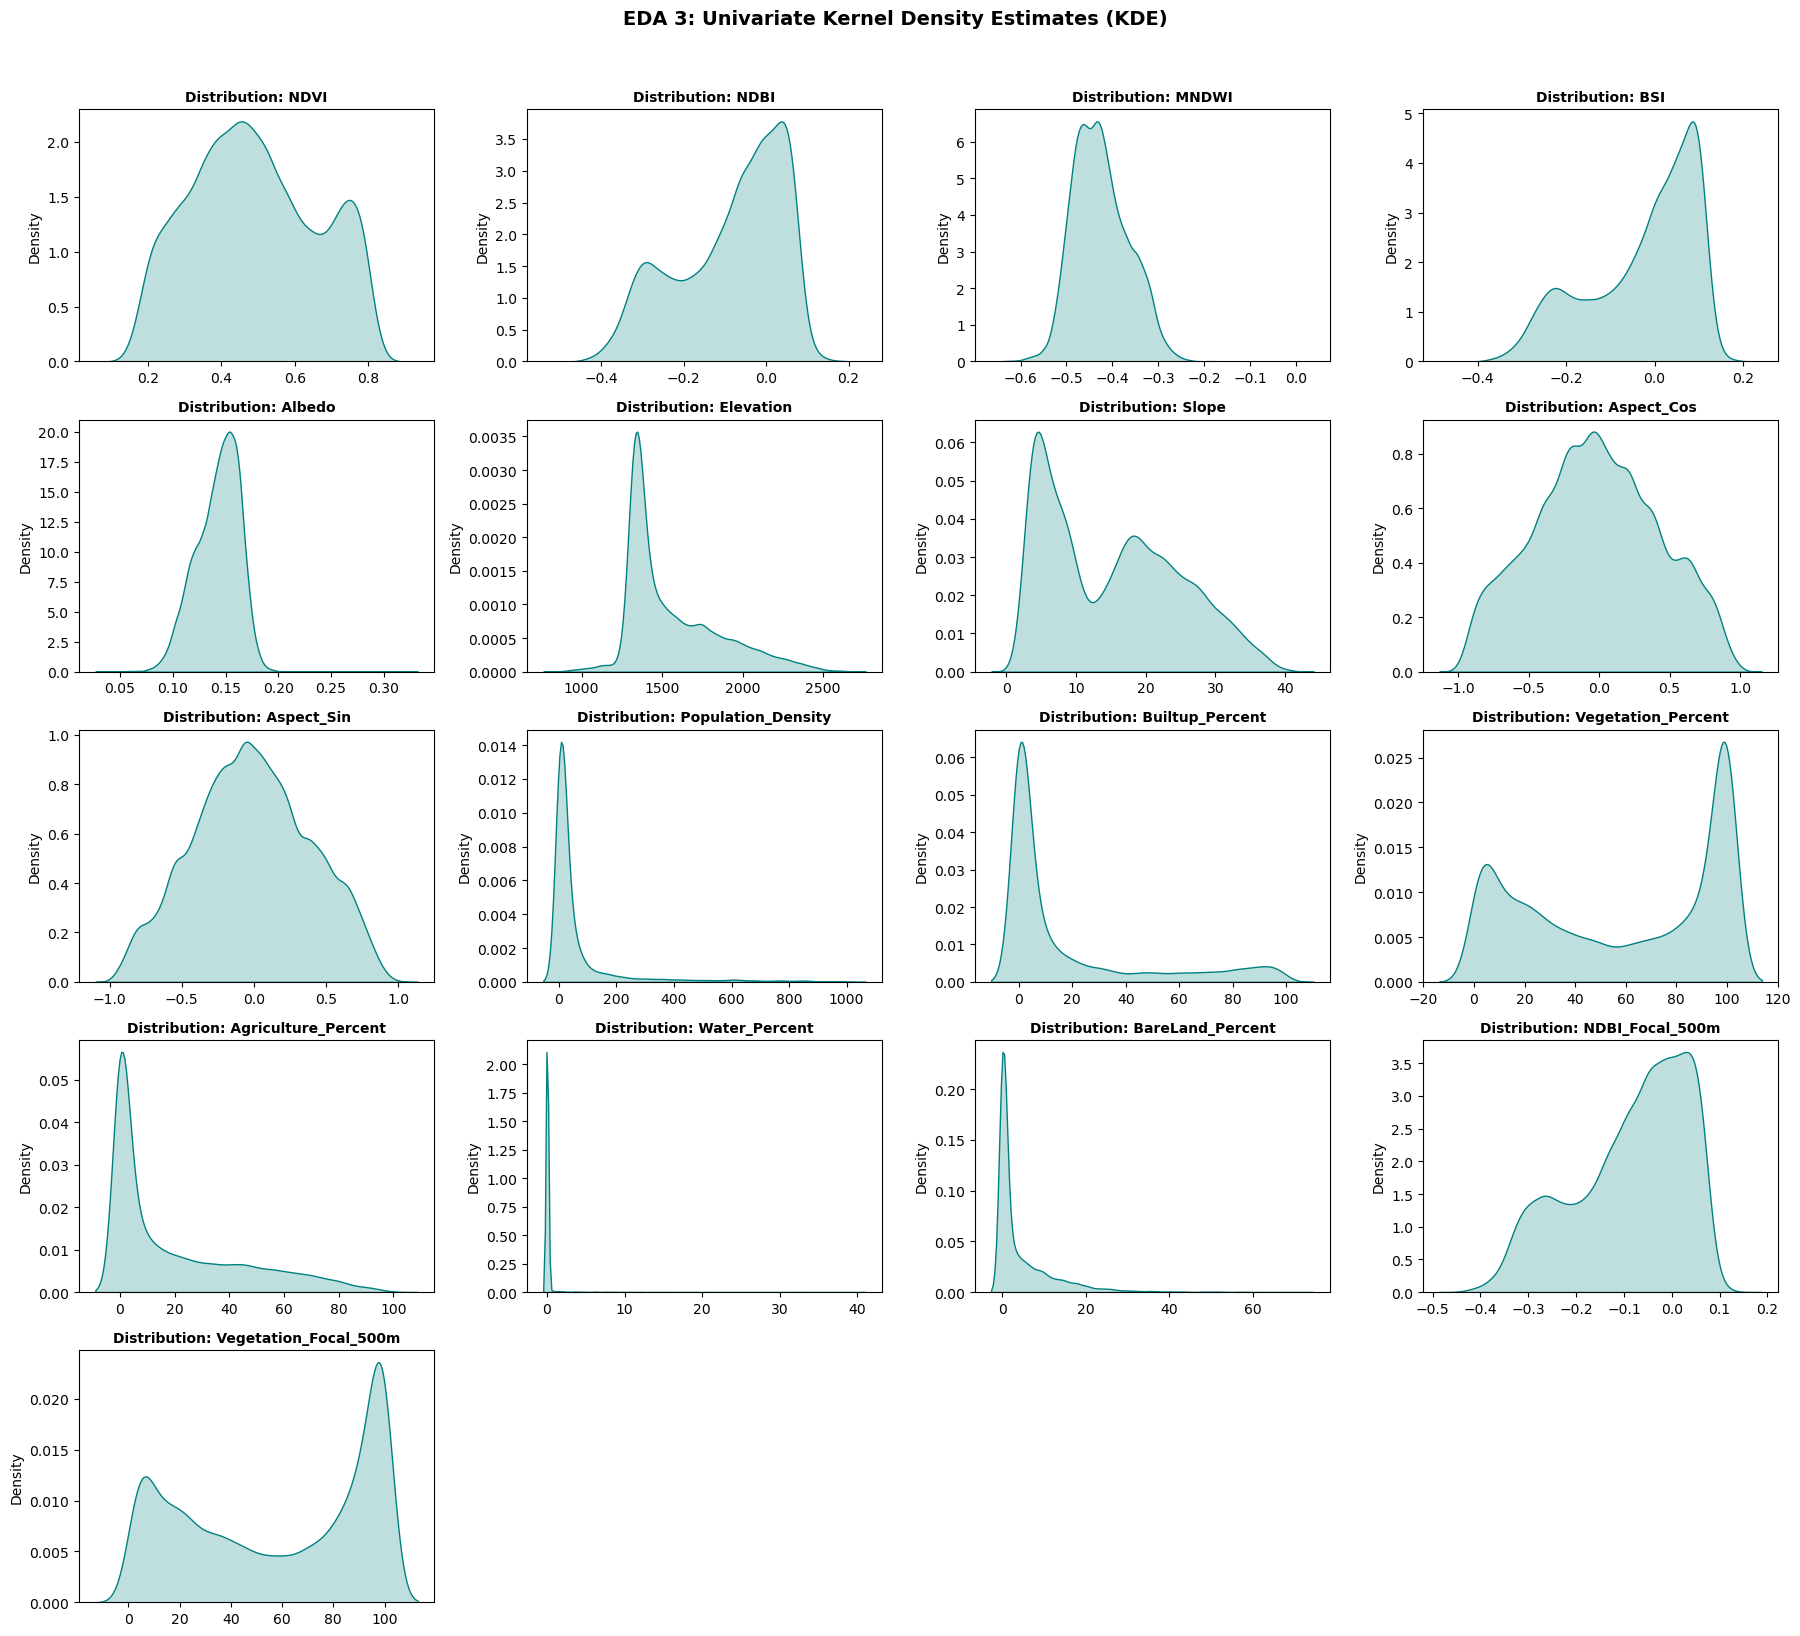

In [15]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(ALL_FEATURES):
    sns.kdeplot(data=df_clean, x=col, ax=axes[i], fill=True, color='teal')
    axes[i].set_title(f"Distribution: {col}", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

# Clean up empty subplots in the 5x4 grid
for j in range(len(ALL_FEATURES), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("EDA 3: Univariate Kernel Density Estimates (KDE)", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #F0F7F4; border-left: 5px solid #1E4D2B; padding: 12px 18px; border-radius: 4px; font-size: 1.2em; line-height: 1.5; color: #2C3E50;">
<strong style="color: #1E4D2B; font-size: 1.2em;">Purpose: Feature Distribution Inspection</strong><br>
• <strong>Goal:</strong> Inspect feature ranges and multimodal distribution shapes.<br>
• <strong>Why:</strong> Verifies physical boundaries and captures rural vs. urban clusters.
</div>

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    EDA 4: Target Variable Analysis (LST)
</h2>

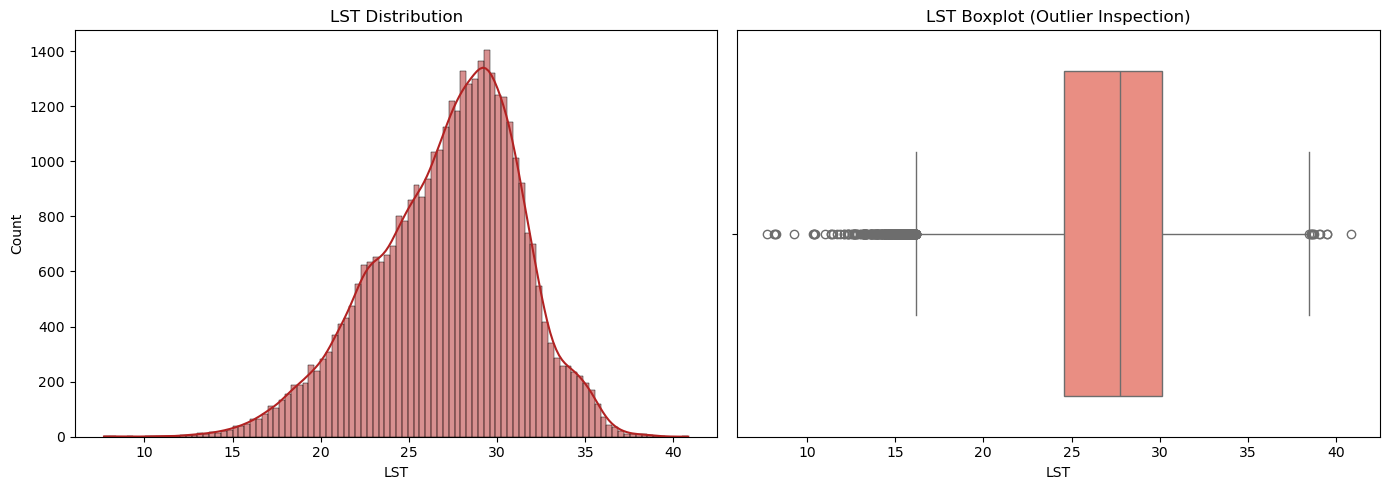

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LST Histogram / KDE
sns.histplot(df_clean["LST"], kde=True, ax=axes[0], color="firebrick")
axes[0].set_title("LST Distribution")

# LST Boxplot (Outlier detection)
sns.boxplot(x=df_clean["LST"], ax=axes[1], color="salmon")
axes[1].set_title("LST Boxplot (Outlier Inspection)")

plt.tight_layout()
plt.show()
print(100*'=')

<div style="background-color: #F0F7F4; border-left: 5px solid #1E4D2B; padding: 12px 18px; border-radius: 4px; font-size: 1.2em; line-height: 1.5; color: #2C3E50;">
<strong style="color: #1E4D2B; font-size: 1.2em;">Purpose: Target Spread & Hotspot Preservation</strong><br>
• <strong>Goal:</strong> Audit temperature spread and extreme heat values.<br>
• <strong>Why:</strong> Ensures genuine UHI heat signals are preserved intact.
</div>

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    EDA 5: Multivariate Analysis (Full Correlation Heatmap / Multicollinearity)
</h2>

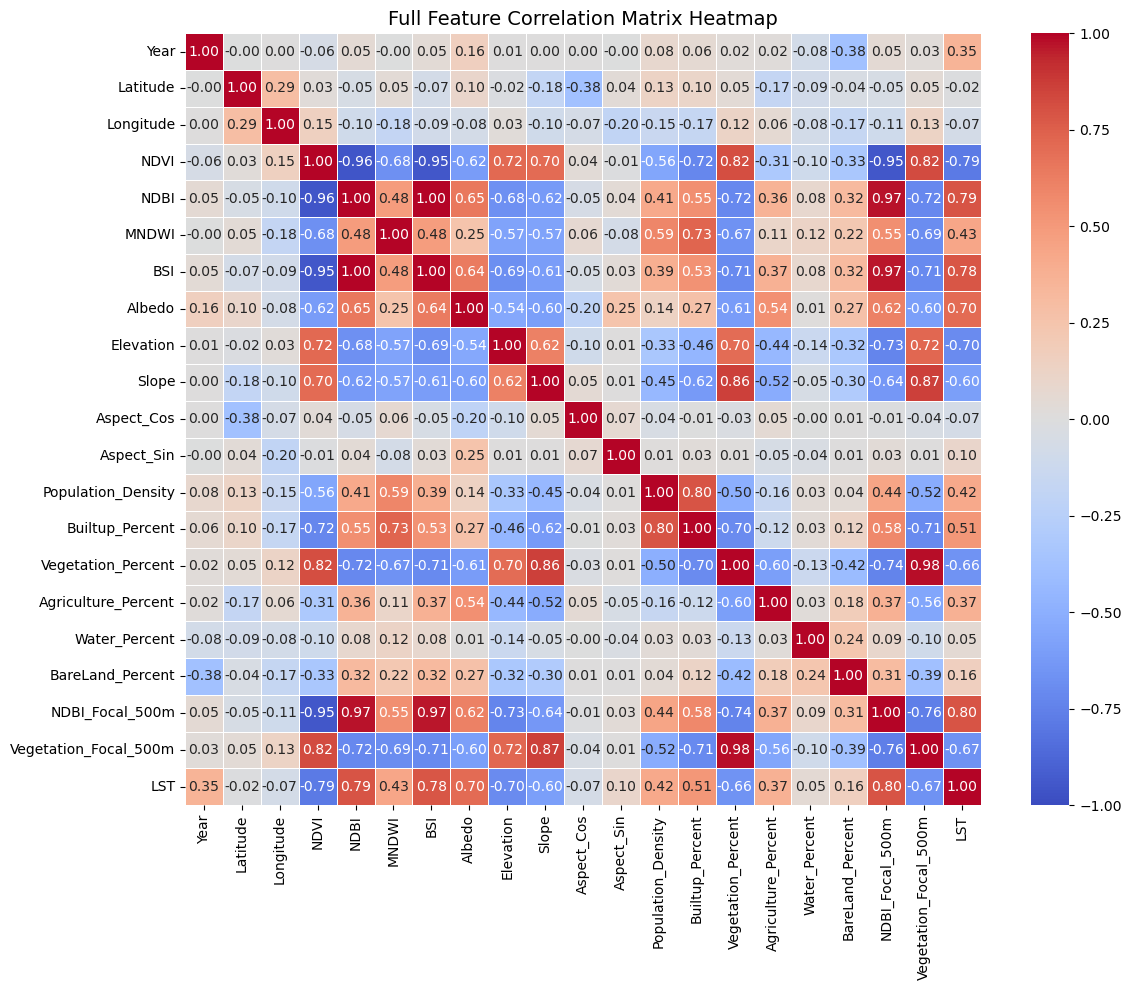

In [17]:
corr_matrix = df_num.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_num.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Full Feature Correlation Matrix Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

<div style="background-color: #F0F7F4; border-left: 5px solid #1E4D2B; padding: 12px 18px; border-radius: 4px; font-size: 1.2em; line-height: 1.5; color: #2C3E50;">
<strong style="color: #1E4D2B; font-size: 1.2em;">Purpose: Pairwise Correlation Audit</strong><br>
• <strong>Goal:</strong> Map feature interactions and dependencies.<br>
• <strong>Why:</strong> Detects severe multicollinearity (e.g., <code>NDVI</code> vs. <code>NDBI</code>).
</div>

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    EDA 6: Target-Specific Analysis (Features vs. LST)
</h2>

In [18]:
corr_table = (
    corr_matrix["LST"]
    .drop("LST")
    .to_frame("correlation_r")
    .assign(abs_r=lambda d: d["correlation_r"].abs())
    .sort_values("abs_r", ascending=False)
    .drop(columns="abs_r")
)
corr_table["relationship"] = np.where(corr_table["correlation_r"] >= 0, "LST increases with feature", "LST decreases with feature")
corr_table.round(3)

,correlation_r,relationship
NDBI_Focal_500m,0.797,LST increases with feature
NDBI,0.791,LST increases with feature
NDVI,-0.786,LST decreases with feature
BSI,0.783,LST increases with feature
Albedo,0.704,LST increases with feature
Elevation,-0.699,LST decreases with feature
Vegetation_Focal_500m,-0.671,LST decreases with feature
Vegetation_Percent,-0.660,LST decreases with feature
Slope,-0.600,LST decreases with feature
Builtup_Percent,0.514,LST increases with feature


<div style="background-color: #F0F7F4; border-left: 5px solid #1E4D2B; padding: 12px 18px; border-radius: 4px; font-size: 1.2em; line-height: 1.5; color: #2C3E50;">
<strong style="color: #1E4D2B; font-size: 1.2em;">Purpose: Thermal Driver Ranking</strong><br>
• <strong>Goal:</strong> Rank top positive and negative drivers of surface heat.<br>
• <strong>Why:</strong> Establishes domain baseline expectations before model training.
</div>

<h1 style="color: #1A365D; border-bottom: 3px solid #1A365D; padding-bottom: 8px; font-weight: bold; margin-top: 25px;">
    6. Data Preparation & Feature Engineering
</h1>

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    6.1 Feature Selection
</h2>

In [19]:
features = [
    'Latitude',
    'Longitude',

    # Spectral Indices
    'NDVI',
    'NDBI',
    'MNDWI',
    'BSI',
    'Albedo',

    # Topography & Solar Exposure
    'Elevation',
    'Slope',
    'Aspect_Cos',
    'Aspect_Sin',

    # Demographics
    'Population_Density',

    # Land Cover Percentages
    'Builtup_Percent',
    'Vegetation_Percent',
    'Agriculture_Percent',
    'Water_Percent',
    'BareLand_Percent',

    # Spatial Microclimate Context (500m Focal)
    'NDBI_Focal_500m',
    'Vegetation_Focal_500m'
]

# Target variable
target = 'LST'

In [20]:
X = df_clean[features]
y = df_clean[target]
groups = df_clean['Grid_ID']  # needed for the spatial train/test split below

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape:   {y.shape}")

Features (X) shape: (37760, 19)
Target (y) shape:   (37760,)


<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    6.2 Data Splitting
</h2>

Each `Grid_ID` is the same physical location sampled across **11 years (2015-2025)**.
A plain random `train_test_split` would put different years of the *same grid cell* into
both train and test, letting the model partly "memorize" a location's coordinates and
elevation instead of learning transferable NDVI/NDBI → LST relationships. A random split
would therefore overstate real-world accuracy.

Instead we use `GroupShuffleSplit` on `Grid_ID` so that **all years of a given cell fall
entirely into either train or test.**

In [21]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print(f"Train set: {X_train.shape[0]} samples across {groups_train.nunique()} grid cells")
print(f"Test set:  {X_test.shape[0]} samples across {groups.iloc[test_idx].nunique()} grid cells")
overlap = set(groups_train) & set(groups.iloc[test_idx])
print(f"Grid cells shared between train and test: {len(overlap)} (should be 0)")

Train set: 30209 samples across 2756 grid cells
Test set:  7551 samples across 689 grid cells
Grid cells shared between train and test: 0 (should be 0)


<h1 style="color: #1A365D; border-bottom: 3px solid #1A365D; padding-bottom: 8px; font-weight: bold; margin-top: 25px;">
    7. Random Forest Model
</h1>

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    7.1 Random Forest Regressor (Without Hyperparameter Tuning)
</h2>

In [22]:
# 1. Define explicit GroupKFold splitter
gkf = GroupKFold(n_splits=5)

baseline_rf = RandomForestRegressor(n_estimators=700, random_state=RANDOM_STATE, n_jobs=-1)

# 2. Pass groups=groups_train and cv=gkf to prevent spatial leakage across folds
cv_scores = cross_val_score(
    baseline_rf, 
    X_train, 
    y_train, 
    groups=groups_train, 
    cv=gkf, 
    scoring='r2', 
    n_jobs=-1
)

print(f"Baseline 5-Fold Group CV R² Score: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

# 3. Fit baseline on full training set and evaluate on test set
baseline_rf.fit(X_train, y_train)
y_pred_base = baseline_rf.predict(X_test)

print(f"Baseline Test MAE:  {mean_absolute_error(y_test, y_pred_base):.4f}")
print(f"Baseline Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):.4f}")
print(f"Baseline Test R²:   {r2_score(y_test, y_pred_base):.4f}")

Baseline 5-Fold Group CV R² Score: 0.8310 (± 0.0029)
Baseline Test MAE:  1.2377
Baseline Test RMSE: 1.6599
Baseline Test R²:   0.8355


In [23]:
# Save baseline RF metrics for later comparison (add to end of cell 41)
mae_rf_base = mean_absolute_error(y_test, y_pred_base)
rmse_rf_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_rf_base = r2_score(y_test, y_pred_base)

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    7.2 Optimized Random Forest Regressor (With Optuna Hyperparameter Tuning)
</h2>

In [24]:
# 1. Define explicit GroupKFold splitter
gkf = GroupKFold(n_splits=5)
start_time_opt = time.time()

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features': trial.suggest_float('max_features', 0.3, 0.8),
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    model = RandomForestRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, groups=groups_train, cv=gkf, scoring='r2', n_jobs=1)
    return scores.mean()

def print_progress(study, trial):
    print(f"  [Trial {trial.number + 1}/{total_trials} Done] -> Current R²: {trial.value:.4f} | Best R²: {study.best_value:.4f}")

total_trials = 20
print(f"Running Random Forest Optuna optimization ({total_trials} trials)...\n")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=total_trials, callbacks=[print_progress])

elapsed_opt = time.time() - start_time_opt
print("\nBest Parameters Found:")
for k, v in study.best_params.items():
    print(f"  - {k}: {v}")
print(f"\nOPTUNA TUNING COMPLETE (Time taken: {elapsed_opt / 60:.2f} mins)")

Running Random Forest Optuna optimization (20 trials)...

  [Trial 1/20 Done] -> Current R²: 0.8244 | Best R²: 0.8244
  [Trial 2/20 Done] -> Current R²: 0.8305 | Best R²: 0.8305
  [Trial 3/20 Done] -> Current R²: 0.8304 | Best R²: 0.8305
  [Trial 4/20 Done] -> Current R²: 0.8270 | Best R²: 0.8305
  [Trial 5/20 Done] -> Current R²: 0.8263 | Best R²: 0.8305
  [Trial 6/20 Done] -> Current R²: 0.8309 | Best R²: 0.8309
  [Trial 7/20 Done] -> Current R²: 0.8211 | Best R²: 0.8309
  [Trial 8/20 Done] -> Current R²: 0.8298 | Best R²: 0.8309
  [Trial 9/20 Done] -> Current R²: 0.8085 | Best R²: 0.8309
  [Trial 10/20 Done] -> Current R²: 0.8315 | Best R²: 0.8315
  [Trial 11/20 Done] -> Current R²: 0.8327 | Best R²: 0.8327
  [Trial 12/20 Done] -> Current R²: 0.8327 | Best R²: 0.8327
  [Trial 13/20 Done] -> Current R²: 0.8322 | Best R²: 0.8327
  [Trial 14/20 Done] -> Current R²: 0.8325 | Best R²: 0.8327
  [Trial 15/20 Done] -> Current R²: 0.8319 | Best R²: 0.8327
  [Trial 16/20 Done] -> Current R²: 

<h3 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    7.2.1 Train Final Random Forest Model & Evaluate
</h3>

In [25]:
rf_best_params = study.best_params.copy()
# rf_best_params['n_estimators'] = 700
rf_best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1})

# Fit tuned model on full training set
tuned_rf = RandomForestRegressor(**rf_best_params)
tuned_rf.fit(X_train, y_train)

# Evaluate on held-out test set
y_pred_rf_tuned = tuned_rf.predict(X_test)

print("--- Tuned Random Forest Test Set Performance ---")
print(f"Tuned Test MAE : {mean_absolute_error(y_test, y_pred_rf_tuned):.4f} °C")
print(f"Tuned Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)):.4f} °C")
print(f"Tuned Test R²  : {r2_score(y_test, y_pred_rf_tuned):.4f}")

--- Tuned Random Forest Test Set Performance ---
Tuned Test MAE : 1.2368 °C
Tuned Test RMSE: 1.6522 °C
Tuned Test R²  : 0.8371


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


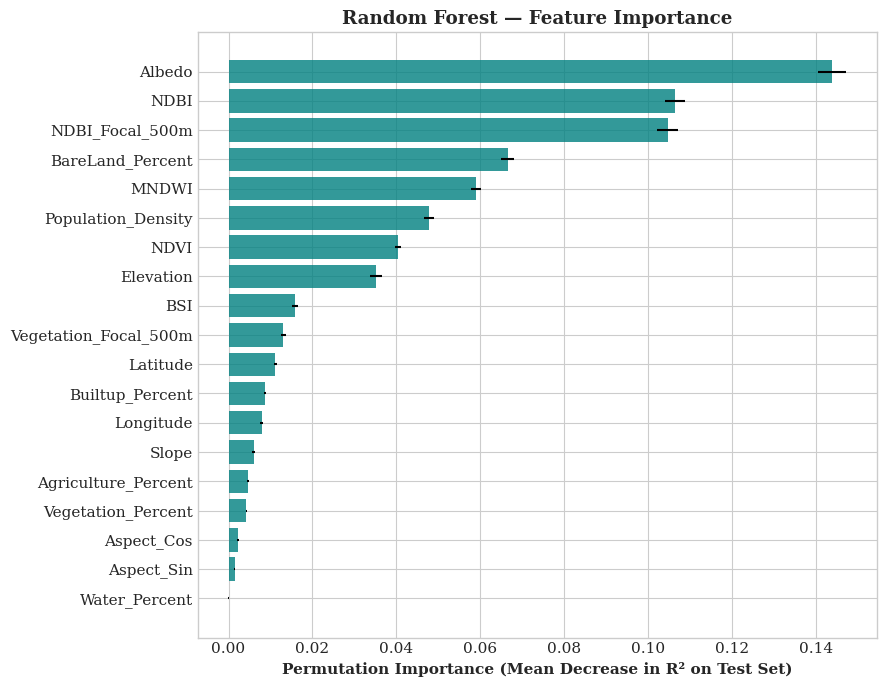

Random Forest permutation importance plot saved successfully to: figures/rf_permutation_importance.png


,Feature,Importance,Std
0,Albedo,0.143781,0.003328
1,NDBI,0.106342,0.002358
2,NDBI_Focal_500m,0.104577,0.002551
3,BareLand_Percent,0.066502,0.001559
4,MNDWI,0.058914,0.001257
5,Population_Density,0.047784,0.001277
6,NDVI,0.040280,0.000720
7,Elevation,0.035121,0.001367
8,BSI,0.015890,0.000732
9,Vegetation_Focal_500m,0.013015,0.000585


In [53]:
# Permutation importance on X_test / y_test (Out-of-sample unbiased evaluation)
perm_result = permutation_importance(
    tuned_rf, X_test, y_test,
    n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1
)

rf_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Plot Permutation Importance
plt.figure(figsize=(9, 7))
plt.barh(rf_importance_df['Feature'][::-1], rf_importance_df['Importance'][::-1],
         xerr=rf_importance_df['Std'][::-1], color='teal', alpha=0.8) 
plt.xlabel("Permutation Importance (Mean Decrease in R² on Test Set)", fontweight='bold')
plt.title("Random Forest — Feature Importance", fontweight='bold')
plt.tight_layout()

# Save the figure in the "figures" folder
os.makedirs("figures", exist_ok=True)  # Ensure the directory exists
rf_perm_importance_path = os.path.join("figures", "rf_permutation_importance.png")
plt.savefig(rf_perm_importance_path, dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

print(f"Random Forest permutation importance plot saved successfully to: {rf_perm_importance_path}")

# Display the importance DataFrame
rf_importance_df

<h3 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    7.2.2 Residual Analysis
</h3>

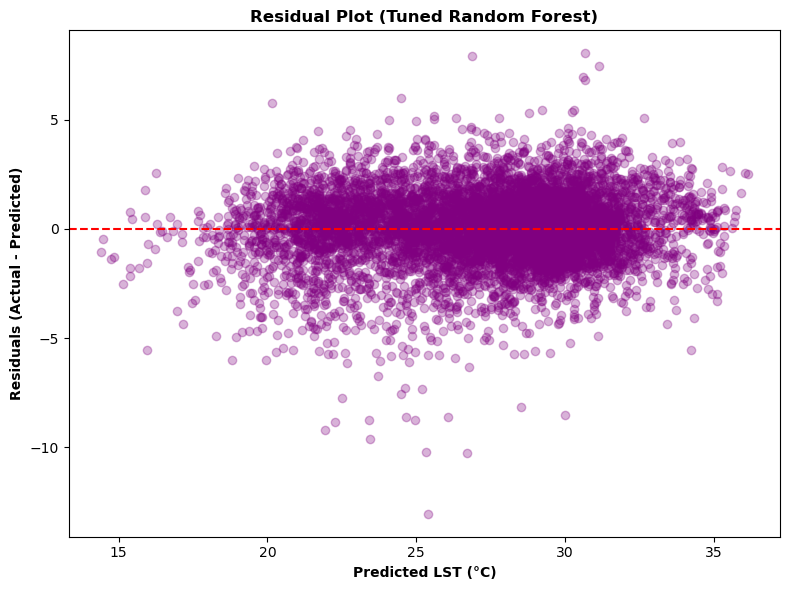

In [27]:
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test
residuals = y_test_arr - y_pred_rf_tuned   

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf_tuned, residuals, alpha=0.3, color="purple")  # FIX: same rename
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted LST (°C)", fontweight="bold")
plt.ylabel("Residuals (Actual - Predicted)", fontweight="bold")
plt.title("Residual Plot (Tuned Random Forest)", fontweight="bold")
plt.tight_layout()
plt.show()

<h1 style="color: #1A365D; border-bottom: 3px solid #1A365D; padding-bottom: 8px; font-weight: bold; margin-top: 25px;">
    8. XGBoost Model Pipeline
</h1>

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    8.1 Install & Import XGBoost
</h2>

In [28]:
try:
    import xgboost as xgb
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb

print(f"xgboost version: {xgb.__version__}")

xgboost version: 3.3.0


<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    8.2 Baseline XGBoost Model
</h2>

In [29]:
print("=" * 60)
print("[1/3] BASELINE XGBOOST TRAINING (WITH EARLY STOPPING)")
print("=" * 60)

start_time = time.time()
gkf = GroupKFold(n_splits=5)

# 5-Fold Grouped Cross-Validation with Early Stopping (unchanged — this part was correct)
cv_scores = []
for tr_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    fold_model = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.1,
        early_stopping_rounds=50,
        eval_metric='rmse',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    fold_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    cv_scores.append(r2_score(y_val, fold_model.predict(X_val)))

print(f"5-Fold CV R² Score: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})")

# --- FIX: carve a validation split OUT OF X_train for early stopping,
# so the test set is never touched until final evaluation ---
final_splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
fit_idx, val_idx = next(final_splitter.split(X_train, y_train, groups=groups_train))

X_fit, X_val_final = X_train.iloc[fit_idx], X_train.iloc[val_idx]
y_fit, y_val_final = y_train.iloc[fit_idx], y_train.iloc[val_idx]

baseline_xgb = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.1,
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Early stopping now watches an internal validation split, NOT X_test
baseline_xgb.fit(X_fit, y_fit, eval_set=[(X_val_final, y_val_final)], verbose=False)

# X_test is touched here for the first and only time — a clean, unbiased evaluation
y_pred = baseline_xgb.predict(X_test)

# --- FIX: save these so cell 60's comparison table doesn't crash ---
rmse_xgb_base = np.sqrt(mean_squared_error(y_test, y_pred))
mae_xgb_base = mean_absolute_error(y_test, y_pred)
r2_xgb_base = r2_score(y_test, y_pred)

print(f"\nBASELINE COMPLETE ({time.time() - start_time:.2f}s)")
print(f"   - Optimal Trees : {baseline_xgb.best_iteration + 1}")
print(f"   - Test RMSE     : {rmse_xgb_base:.4f} °C")
print(f"   - Test MAE      : {mae_xgb_base:.4f} °C")
print(f"   - Test R²       : {r2_xgb_base:.4f}")
print("=" * 60)

[1/3] BASELINE XGBOOST TRAINING (WITH EARLY STOPPING)
5-Fold CV R² Score: 0.8405 (± 0.0043)

BASELINE COMPLETE (8.02s)
   - Optimal Trees : 569
   - Test RMSE     : 1.6092 °C
   - Test MAE      : 1.2160 °C
   - Test R²       : 0.8454


<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    8.3 Optuna Hyperparameter Tuning for XGBoost
</h2>

In [30]:
print("=" * 60)
print("[2/3] STARTING OPTUNA TUNING FOR XGBOOST (HIGH ESTIMATORS)")
print("=" * 60)

start_time_xgb_opt = time.time()
gkf = GroupKFold(n_splits=5)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 800, 2000, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 0.1, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0, log=True),
        
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(
        model, 
        X_train, 
        y_train, 
        groups=groups_train, 
        cv=gkf, 
        scoring='r2', 
        n_jobs=-1
    )
    return scores.mean()

def print_xgb_progress(study, trial):
    print(f"   [Trial {trial.number + 1}/{total_trials_xgb} Done] -> Current R²: {trial.value:.4f} | Best R²: {study.best_value:.4f}")

# Search for parameters that maximize R2
study_xgb = optuna.create_study(direction='maximize')
total_trials_xgb = 20

print(f"Running XGBoost Optuna optimization ({total_trials_xgb} trials)...")
study_xgb.optimize(objective_xgb, n_trials=total_trials_xgb, callbacks=[print_xgb_progress])

elapsed_xgb_opt = time.time() - start_time_xgb_opt

print("\nBest Parameters Found:")
for k, v in study_xgb.best_params.items():
    print(f"  - {k}: {v}")
print(f"\nOPTUNA TUNING COMPLETE (Time taken: {elapsed_xgb_opt/60:.2f} mins)")

[2/3] STARTING OPTUNA TUNING FOR XGBOOST (HIGH ESTIMATORS)
Running XGBoost Optuna optimization (20 trials)...
   [Trial 1/20 Done] -> Current R²: 0.8317 | Best R²: 0.8317
   [Trial 2/20 Done] -> Current R²: 0.8455 | Best R²: 0.8455
   [Trial 3/20 Done] -> Current R²: 0.8443 | Best R²: 0.8455
   [Trial 4/20 Done] -> Current R²: 0.8448 | Best R²: 0.8455
   [Trial 5/20 Done] -> Current R²: 0.8457 | Best R²: 0.8457
   [Trial 6/20 Done] -> Current R²: 0.8424 | Best R²: 0.8457
   [Trial 7/20 Done] -> Current R²: 0.8451 | Best R²: 0.8457
   [Trial 8/20 Done] -> Current R²: 0.8388 | Best R²: 0.8457
   [Trial 9/20 Done] -> Current R²: 0.8291 | Best R²: 0.8457
   [Trial 10/20 Done] -> Current R²: 0.8405 | Best R²: 0.8457
   [Trial 11/20 Done] -> Current R²: 0.8429 | Best R²: 0.8457
   [Trial 12/20 Done] -> Current R²: 0.8459 | Best R²: 0.8459
   [Trial 13/20 Done] -> Current R²: 0.8448 | Best R²: 0.8459
   [Trial 14/20 Done] -> Current R²: 0.8457 | Best R²: 0.8459
   [Trial 15/20 Done] -> Curren

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    8.4 Train Final XGBoost Model
</h2>

In [31]:
print("=" * 60)
print("[3/3] TRAINING FINAL TUNED XGBOOST MODEL")
print("=" * 60)

start_time_xgb_final = time.time()

# 1. Initialize Model with Best Hyperparameters
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params['random_state'] = RANDOM_STATE
best_xgb_params['n_jobs'] = -1

tuned_xgb = xgb.XGBRegressor(**best_xgb_params)

# 2. Fit Tuned Model
print("Fitting tuned XGBoost model on training set...")
tuned_xgb.fit(X_train, y_train)

# 3. Predict on Test Set
print("Evaluating on test set...")
y_pred_xgb_tuned = tuned_xgb.predict(X_test)

elapsed_xgb_final = time.time() - start_time_xgb_final

# 4. Evaluate Metrics
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print(f"TUNED XGBOOST COMPLETE (Time taken: {elapsed_xgb_final:.2f}s)")
print(f"   - RMSE : {rmse_xgb_tuned:.4f} \u00b0C")
print(f"   - MAE  : {mae_xgb_tuned:.4f} \u00b0C")
print(f"   - R\u00b2   : {r2_xgb_tuned:.4f}")
print("=" * 60 + "\n")

[3/3] TRAINING FINAL TUNED XGBOOST MODEL
Fitting tuned XGBoost model on training set...
Evaluating on test set...
TUNED XGBOOST COMPLETE (Time taken: 8.44s)
   - RMSE : 1.5597 °C
   - MAE  : 1.1706 °C
   - R²   : 0.8548



<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    8.5 Residuals (Actual LST - Predicted LST) for the tuned XGBoost model
</h2>

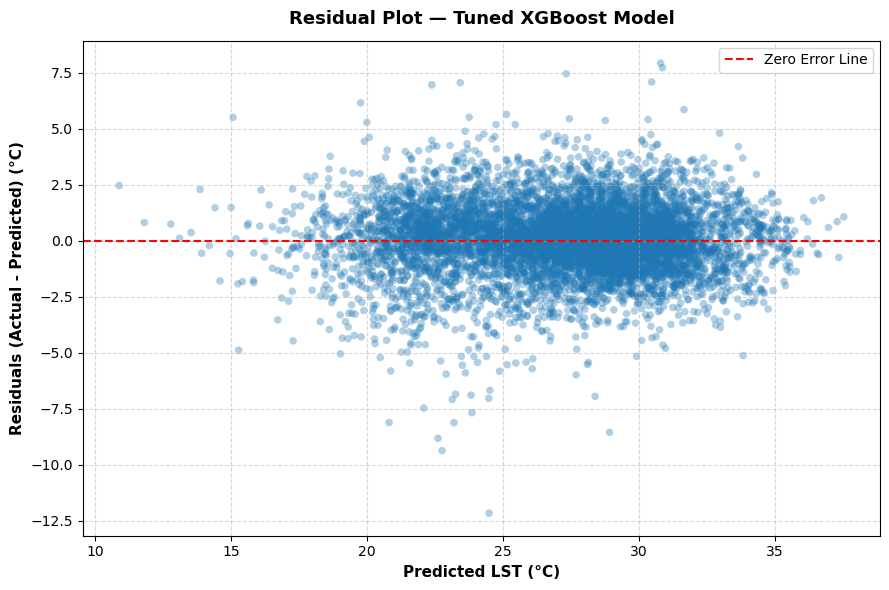

In [32]:
y_test_arr = y_test.values if hasattr(y_test, "values") else y_test
residuals_xgb = y_test_arr - y_pred_xgb_tuned

plt.figure(figsize=(9, 6))
plt.scatter(
    y_pred_xgb_tuned,
    residuals_xgb,
    alpha=0.35,
    color="#1f77b4",
    edgecolors="none",
    s=30,
)
plt.axhline(0, color="red", linestyle="--", linewidth=1.5, label="Zero Error Line")

plt.title(
    "Residual Plot — Tuned XGBoost Model", fontsize=13, fontweight="bold", pad=12
)
plt.xlabel("Predicted LST (\u00b0C)", fontsize=11, fontweight="bold")
plt.ylabel("Residuals (Actual - Predicted) (\u00b0C)", fontsize=11, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

,Feature,Importance_Mean,Importance_Std
0,NDBI_Focal_500m,0.234442,0.003961
1,NDBI,0.233202,0.004123
2,Albedo,0.218049,0.004260
3,NDVI,0.216632,0.003587
4,MNDWI,0.197106,0.003404
5,Population_Density,0.139652,0.003606
6,BareLand_Percent,0.063808,0.001541
7,BSI,0.059459,0.001595
8,Elevation,0.044342,0.001683
9,Latitude,0.035960,0.001663


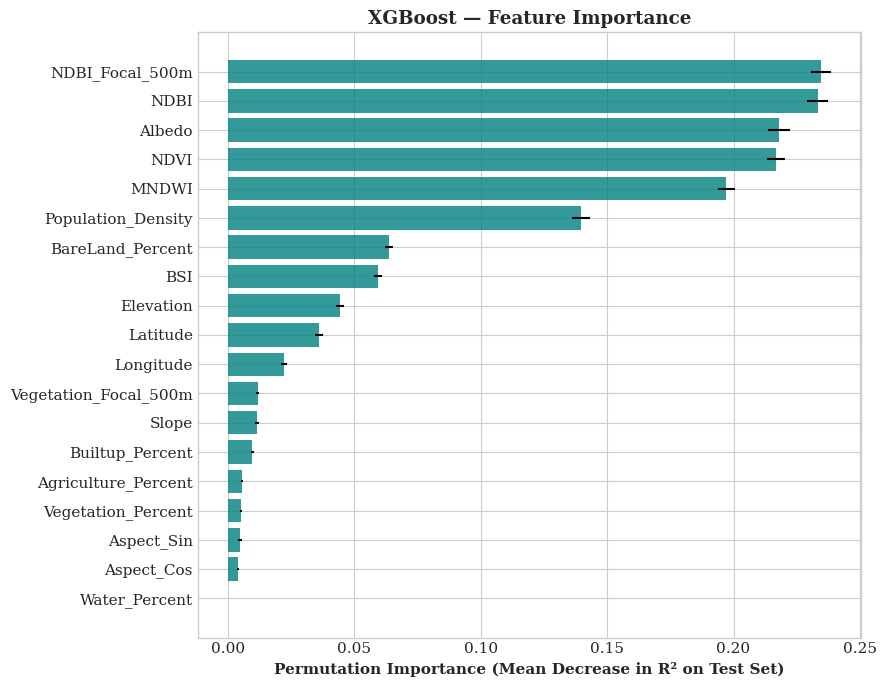

Permutation importance plot saved successfully to: figures/xgb_permutation_importance.png


In [ ]:
# Compute Permutation Importance on the Test Set for XGBoost
xgb_perm_result = permutation_importance(
    tuned_xgb, 
    X_test, 
    y_test, 
    n_repeats=15, 
    random_state=RANDOM_STATE, 
    scoring='r2', 
    n_jobs=-1
)

# Organize into a DataFrame
xgb_perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': xgb_perm_result.importances_mean,
    'Importance_Std': xgb_perm_result.importances_std
}).sort_values(by='Importance_Mean', ascending=False).reset_index(drop=True)

display(xgb_perm_df)

# Plot Permutation Importance
plt.figure(figsize=(9, 7))
plt.barh(xgb_perm_df['Feature'][::-1], xgb_perm_df['Importance_Mean'][::-1],
         xerr=xgb_perm_df['Importance_Std'][::-1], color='teal', alpha=0.8) 
plt.xlabel("Permutation Importance (Mean Decrease in R² on Test Set)", fontweight='bold')
plt.title("XGBoost — Feature Importance", fontweight='bold')
plt.tight_layout()

# Save the figure in the "figures" folder
os.makedirs("figures", exist_ok=True)  # Ensure the directory exists
perm_importance_path = os.path.join("figures", "xgb_permutation_importance.png")
plt.savefig(perm_importance_path, dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

print(f"Permutation importance plot saved successfully to: {perm_importance_path}")

<h2 style="color: #2B6CB0; font-weight: 600; margin-top: 15px; border-bottom: 1px solid #E2E8F0; padding-bottom: 4px;">
    8.6 XGBoost Summary Comparison Table
</h2>

In [34]:
comparison_xgb_df = pd.DataFrame({
    'Metric': ['RMSE (\u00b0C)', 'MAE (\u00b0C)', 'R\u00b2 Score'],
    'Baseline XGBoost': [rmse_xgb_base, mae_xgb_base, r2_xgb_base],
    'Tuned XGBoost (Optuna)': [rmse_xgb_tuned, mae_xgb_tuned, r2_xgb_tuned]
})

print("XGBoost MODEL TRAINING SUMMARY")
print("=" * 60)
print(comparison_xgb_df.to_string(index=False))
print("=" * 60)

XGBoost MODEL TRAINING SUMMARY
   Metric  Baseline XGBoost  Tuned XGBoost (Optuna)
RMSE (°C)          1.609164                1.559672
 MAE (°C)          1.216044                1.170604
 R² Score          0.845434                0.854796


In [35]:
final_comparison_df = pd.DataFrame({
    'Metric': ['RMSE (°C)', 'MAE (°C)', 'R² Score'],
    'RF Baseline': [rmse_rf_base, mae_rf_base, r2_rf_base],
    'RF Tuned': [np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)),
                 mean_absolute_error(y_test, y_pred_rf_tuned),
                 r2_score(y_test, y_pred_rf_tuned)],
    'XGBoost Baseline': [rmse_xgb_base, mae_xgb_base, r2_xgb_base],
    'XGBoost Tuned': [rmse_xgb_tuned, mae_xgb_tuned, r2_xgb_tuned]
})

print("=" * 70)
print("FINAL MODEL COMPARISON — RANDOM FOREST vs XGBOOST")
print("=" * 70)
print(final_comparison_df.to_string(index=False))
print("=" * 70)

best_model = final_comparison_df.loc[2, ['RF Tuned', 'XGBoost Tuned']].astype(float).idxmax()
print(f"\nOptimal Model based on Test R²: {best_model}")

FINAL MODEL COMPARISON — RANDOM FOREST vs XGBOOST
   Metric  RF Baseline  RF Tuned  XGBoost Baseline  XGBoost Tuned
RMSE (°C)     1.659901  1.652172          1.609164       1.559672
 MAE (°C)     1.237672  1.236848          1.216044       1.170604
 R² Score     0.835534  0.837062          0.845434       0.854796

Optimal Model based on Test R²: XGBoost Tuned


In [ ]:
# Ensure the directory for saving models exists
os.makedirs("models", exist_ok=True)

# Save baseline models
joblib.dump(baseline_rf, "models/Kathmandu/baseline_random_forest_model.pkl")
joblib.dump(baseline_xgb, "models/Kathmandu/baseline_xgboost_model.pkl")

# Save tuned models
joblib.dump(tuned_rf, "models/Kathmandu/best_random_forest_model.pkl")
joblib.dump(tuned_xgb, "models/Kathmandu/best_xgboost_model.pkl")

print("All models (baseline and tuned) successfully saved to disk!")

All models (baseline and tuned) successfully saved to disk!


In [ ]:
# Load baseline models
baseline_rf = joblib.load("models/Kathmandu/baseline_random_forest_model.pkl")
baseline_xgb = joblib.load("models/Kathmandu/baseline_xgboost_model.pkl")

# Load tuned models
tuned_rf = joblib.load("models/Kathmandu/best_random_forest_model.pkl")
tuned_xgb = joblib.load("models/Kathmandu/best_xgboost_model.pkl")

print("All models (baseline and tuned) successfully loaded from disk!")

All models (baseline and tuned) successfully loaded from disk!


In [38]:
# Make predictions using the loaded models
y_pred_rf_baseline = baseline_rf.predict(X_test)
y_pred_xgb_baseline = baseline_xgb.predict(X_test)

y_pred_rf_tuned = tuned_rf.predict(X_test)
y_pred_xgb_tuned = tuned_xgb.predict(X_test)

# Evaluate the models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Compute metrics for baseline models
rf_baseline_mae = mean_absolute_error(y_test, y_pred_rf_baseline)
rf_baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_baseline))
rf_baseline_r2 = r2_score(y_test, y_pred_rf_baseline)

xgb_baseline_mae = mean_absolute_error(y_test, y_pred_xgb_baseline)
xgb_baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_baseline))
xgb_baseline_r2 = r2_score(y_test, y_pred_xgb_baseline)

# Compute metrics for tuned models
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)

xgb_tuned_mae = mean_absolute_error(y_test, y_pred_xgb_tuned)
xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
xgb_tuned_r2 = r2_score(y_test, y_pred_xgb_tuned)

# Print metrics
print("Baseline Random Forest Metrics:", rf_baseline_mae, rf_baseline_rmse, rf_baseline_r2)
print("Baseline XGBoost Metrics:", xgb_baseline_mae, xgb_baseline_rmse, xgb_baseline_r2)
print("Tuned Random Forest Metrics:", rf_tuned_mae, rf_tuned_rmse, rf_tuned_r2)
print("Tuned XGBoost Metrics:", xgb_tuned_mae, xgb_tuned_rmse, xgb_tuned_r2)

Baseline Random Forest Metrics: 1.2376717318048354 1.6599009661436808 0.835533543223467
Baseline XGBoost Metrics: 1.216043861663693 1.6091638879632724 0.8454341536255757
Tuned Random Forest Metrics: 1.2368478075731322 1.6521724085235876 0.8370615010922225
Tuned XGBoost Metrics: 1.170604172063249 1.5596715986576137 0.8547957565537481


# MODEL PERFORMANCE PLOTS

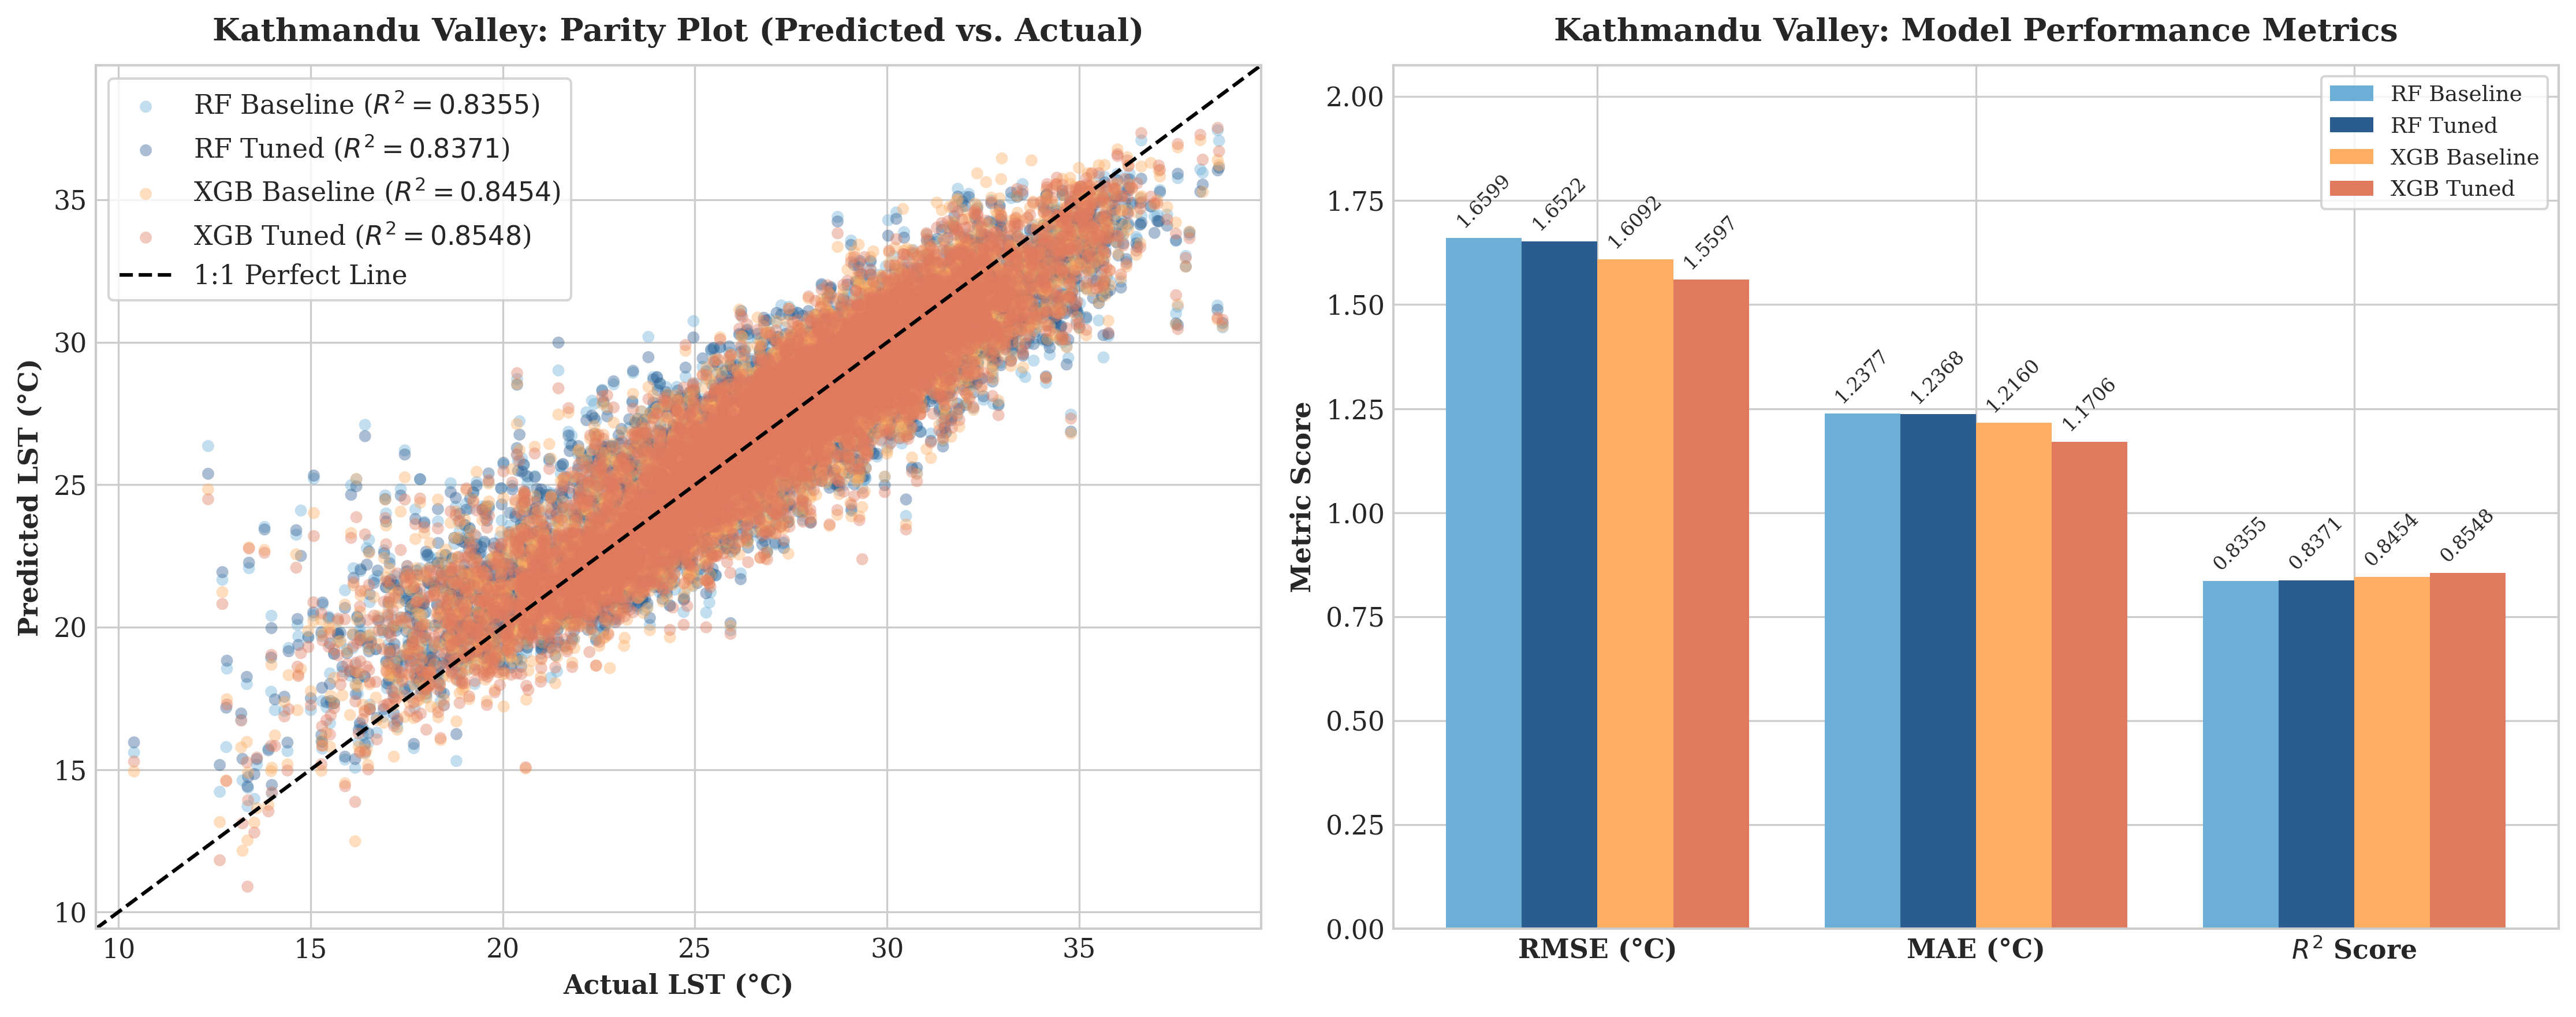

Kathmandu plot saved successfully to: figures/model_performance_kathmandu_all_models.png


In [51]:
# Ensure directory exists
os.makedirs("figures", exist_ok=True)

# 1. Compute evaluation metrics dynamically from trained model predictions
# Baseline Random Forest
rf_baseline_mae = mean_absolute_error(y_test, y_pred_rf_baseline)
rf_baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_baseline))
rf_baseline_r2 = r2_score(y_test, y_pred_rf_baseline)

# Tuned Random Forest
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)

# Baseline XGBoost
xgb_baseline_mae = mean_absolute_error(y_test, y_pred_xgb_baseline)
xgb_baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_baseline))
xgb_baseline_r2 = r2_score(y_test, y_pred_xgb_baseline)

# Tuned XGBoost
xgb_tuned_mae = mean_absolute_error(y_test, y_pred_xgb_tuned)
xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
xgb_tuned_r2 = r2_score(y_test, y_pred_xgb_tuned)

# Set publication style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.family": "serif", "font.size": 11})

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=300)

# ==============================================================================
# KATHMANDU VALLEY MODEL PERFORMANCE VISUALIZATION
# ==============================================================================
# 2. Parity Plot (Predicted vs. Actual)
ax1 = axes[0]
ax1.scatter(
    y_test,
    y_pred_rf_baseline,
    alpha=0.4,
    color="#6baed6",
    edgecolors="none",
    s=25,
    label=f"RF Baseline ($R^2={rf_baseline_r2:.4f}$)",
)
ax1.scatter(
    y_test,
    y_pred_rf_tuned,
    alpha=0.4,
    color="#2b5c8f",
    edgecolors="none",
    s=25,
    label=f"RF Tuned ($R^2={rf_tuned_r2:.4f}$)",
)
ax1.scatter(
    y_test,
    y_pred_xgb_baseline,
    alpha=0.4,
    color="#fdae61",
    edgecolors="none",
    s=25,
    label=f"XGB Baseline ($R^2={xgb_baseline_r2:.4f}$)",
)
ax1.scatter(
    y_test,
    y_pred_xgb_tuned,
    alpha=0.4,
    color="#e07a5f",
    edgecolors="none",
    s=25,
    label=f"XGB Tuned ($R^2={xgb_tuned_r2:.4f}$)",
)

# 1:1 Reference Line
min_val = min(
    y_test.min(),
    y_pred_rf_baseline.min(),
    y_pred_rf_tuned.min(),
    y_pred_xgb_baseline.min(),
    y_pred_xgb_tuned.min(),
) - 1
max_val = max(
    y_test.max(),
    y_pred_rf_baseline.max(),
    y_pred_rf_tuned.max(),
    y_pred_xgb_baseline.max(),
    y_pred_xgb_tuned.max(),
) + 1
ax1.plot(
    [min_val, max_val],
    [min_val, max_val],
    "k--",
    lw=1.5,
    label="1:1 Perfect Line",
)

ax1.set_xlim(min_val, max_val)
ax1.set_ylim(min_val, max_val)
ax1.set_xlabel("Actual LST (°C)", fontweight="bold")
ax1.set_ylabel("Predicted LST (°C)", fontweight="bold")
ax1.set_title(
    "Kathmandu Valley: Parity Plot (Predicted vs. Actual)",
    fontweight="bold",
    pad=10,
)
ax1.legend(frameon=True, loc="upper left")

# 3. Dynamic Metric Comparison Bar Chart
ax2 = axes[1]
ktm_metrics = pd.DataFrame(
    {
        "Metric": ["RMSE (°C)", "MAE (°C)", "$R^2$ Score"],
        "RF Baseline": [rf_baseline_rmse, rf_baseline_mae, rf_baseline_r2],
        "RF Tuned": [rf_tuned_rmse, rf_tuned_mae, rf_tuned_r2],
        "XGB Baseline": [xgb_baseline_rmse, xgb_baseline_mae, xgb_baseline_r2],
        "XGB Tuned": [xgb_tuned_rmse, xgb_tuned_mae, xgb_tuned_r2],
    }
)
x = np.arange(len(ktm_metrics))  # Positions for the metrics
width = 0.2 

# Plot bars for each model
rects1 = ax2.bar(
    x - 1.5 * width,
    ktm_metrics["RF Baseline"],
    width,
    label="RF Baseline",
    color="#6baed6",
)
rects2 = ax2.bar(
    x - 0.5 * width,
    ktm_metrics["RF Tuned"],
    width,
    label="RF Tuned",
    color="#2b5c8f",
)
rects3 = ax2.bar(
    x + 0.5 * width,
    ktm_metrics["XGB Baseline"],
    width,
    label="XGB Baseline",
    color="#fdae61",
)
rects4 = ax2.bar(
    x + 1.5 * width,
    ktm_metrics["XGB Tuned"],
    width,
    label="XGB Tuned",
    color="#e07a5f",
)

# Add labels, title, and legend
ax2.set_xticks(x)
ax2.set_xticklabels(ktm_metrics["Metric"], fontweight="bold")
ax2.set_ylabel("Metric Score", fontweight="bold")
ax2.set_title(
    "Kathmandu Valley: Model Performance Metrics", fontweight="bold", pad=10
)
ax2.legend(frameon=True, loc="upper right", fontsize=9)

# Dynamically set Y limit to fit all bars and annotations cleanly
max_metric_val = max(
    rf_baseline_rmse,
    rf_tuned_rmse,
    xgb_baseline_rmse,
    xgb_tuned_rmse,
    rf_baseline_mae,
    rf_tuned_mae,
    xgb_baseline_mae,
    xgb_tuned_mae,
    rf_baseline_r2,
    rf_tuned_r2,
    xgb_baseline_r2,
    xgb_tuned_r2,
)
ax2.set_ylim(0, max_metric_val * 1.25)

# Annotate values dynamically on top of bars with slanted text
ax2.bar_label(rects1, padding=3, fmt="%.4f", fontsize=8, rotation=45)
ax2.bar_label(rects2, padding=3, fmt="%.4f", fontsize=8, rotation=45)
ax2.bar_label(rects3, padding=3, fmt="%.4f", fontsize=8, rotation=45)
ax2.bar_label(rects4, padding=3, fmt="%.4f", fontsize=8, rotation=45)

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure in the "figures" folder
ktm_path = os.path.join("figures", "model_performance_kathmandu_all_models.png")
plt.savefig(ktm_path, dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

print(f"Kathmandu plot saved successfully to: {ktm_path}")